# 📊 Experiment0 Post-Analysis: Method Selection for Full Benchmarking

**Objective**: Analyze Experiment0 results to identify the best-performing methods for the full benchmark (Experiment1).

---

## Overview

**Experiment0** is a pilot study designed to:
1. Test all available methods on a subset of datasets
2. Identify high-performing methods worth including in the full benchmark
3. Filter out underperforming or problematic methods
4. Balance performance vs. computational cost

This notebook provides:
- **Performance Analysis**: Heatmaps and rankings for PD and LGD tasks
- **Training Time Analysis**: Computational efficiency of each method
- **Method Selection**: Data-driven recommendations for Experiment1
- **Statistical Testing**: Significance of performance differences

---

## 1. Setup & Configuration

In [1]:
# Standard imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Setup paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results" / "experiment0"
SUMMARY_DIR = RESULTS_DIR / "summary"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print(f"📂 Project root: {PROJECT_ROOT}")
print(f"📂 Results directory: {RESULTS_DIR}")
print(f"📂 Summary directory: {SUMMARY_DIR}")
print(f"📂 Figures directory: {FIGURES_DIR}")

📂 Project root: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit
📂 Results directory: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment0
📂 Summary directory: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment0\summary
📂 Figures directory: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment0\figures


In [2]:
# Plotting configuration
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

# Color schemes
CMAP_PERFORMANCE = 'RdYlGn'  # Red (bad) to Green (good)
CMAP_TIME = 'YlOrRd'  # Yellow (fast) to Red (slow)

## 2. Data Loading

In [3]:
# Load raw and aggregated results
pd_raw = pd.read_csv(SUMMARY_DIR / "summary_pd_raw.csv")
pd_agg = pd.read_csv(SUMMARY_DIR / "summary_pd_aggregated.csv")
lgd_raw = pd.read_csv(SUMMARY_DIR / "summary_lgd_raw.csv")
lgd_agg = pd.read_csv(SUMMARY_DIR / "summary_lgd_aggregated.csv")

print("\n📊 Data Overview:")
print(f"\nPD (Probability of Default):")
print(f"  - Raw results: {len(pd_raw)} fold results")
print(f"  - Methods: {pd_raw['method'].nunique()}")
print(f"  - Datasets: {pd_raw['dataset'].nunique()}")
print(f"  - Methods: {sorted(pd_raw['method'].unique())}")

print(f"\nLGD (Loss Given Default):")
print(f"  - Raw results: {len(lgd_raw)} fold results")
print(f"  - Methods: {lgd_raw['method'].nunique()}")
print(f"  - Datasets: {lgd_raw['dataset'].nunique()}")
print(f"  - Methods: {sorted(lgd_raw['method'].unique())}")


📊 Data Overview:

PD (Probability of Default):
  - Raw results: 218 fold results
  - Methods: 37
  - Datasets: 3
  - Methods: ['LogReg', 'NCM', 'NaiveBayes', 'RandomForest', 'amformer', 'autoint', 'bishop', 'catboost', 'danets', 'dcn2', 'dummy', 'excelformer', 'ftt', 'grownet', 'knn', 'lightgbm', 'mlp', 'mlp_plr', 'modernNCA', 'node', 'protogate', 'ptarl', 'realmlp', 'resnet', 'snn', 'svm', 'switchtab', 't2gformer', 'tabcaps', 'tabicl', 'tabm', 'tabnet', 'tabpfn', 'tabpfn_v2', 'tabtransformer', 'tangos', 'xgboost']

LGD (Loss Given Default):
  - Raw results: 178 fold results
  - Methods: 31
  - Datasets: 3
  - Methods: ['LinearRegression', 'RandomForest', 'amformer', 'autoint', 'bishop', 'catboost', 'danets', 'dcn2', 'dnnr', 'excelformer', 'ftt', 'grownet', 'knn', 'lightgbm', 'mlp', 'mlp_plr', 'modernNCA', 'node', 'ptarl', 'realmlp', 'resnet', 'snn', 'svm', 'switchtab', 't2gformer', 'tabm', 'tabnet', 'tabpfn_v2', 'tabtransformer', 'tangos', 'xgboost']


## 3. Performance Analysis: PD Task

### 3.1 Performance Heatmaps (Methods × Datasets)

In [4]:
def create_performance_heatmap(df, metric, task_name, cmap='RdYlGn', figsize=(14, 8)):
    """
    Create a heatmap showing method performance across datasets.
    
    Args:
        df: Aggregated dataframe
        metric: Metric to visualize (e.g., 'AUC', 'F1', 'R2')
        task_name: 'PD' or 'LGD'
        cmap: Colormap
        figsize: Figure size
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df.columns:
        print(f"⚠️  Metric '{metric}' not found in data")
        return None
    
    # Create pivot table
    pivot = df.pivot(index='method', columns='dataset', values=mean_col)
    
    # Sort methods by average performance
    method_means = pivot.mean(axis=1).sort_values(ascending=False)
    pivot = pivot.loc[method_means.index]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Determine vmin/vmax for consistent color scaling
    vmin = pivot.min().min()
    vmax = pivot.max().max()
    
    # Create heatmap
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.3f',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar_kws={'label': metric},
        linewidths=0.5,
        ax=ax
    )
    
    ax.set_title(f'{task_name} Performance: {metric} (Methods × Datasets)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
    ax.set_ylabel('Method', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    
    # Save figure
    filename = FIGURES_DIR / f"{task_name.lower()}_heatmap_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename.name}")
    
    return fig, pivot

Creating PD AUC heatmap...
✅ Saved: pd_heatmap_auc.png


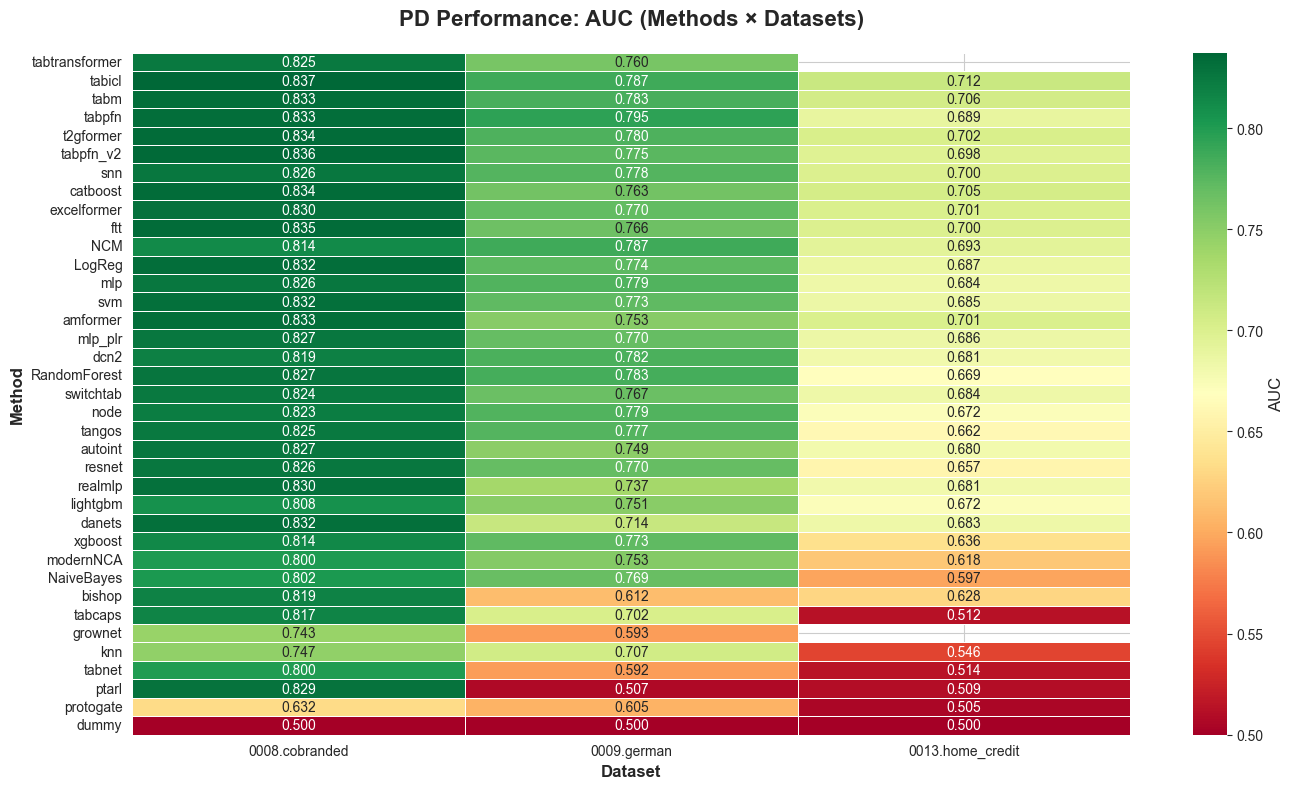

In [5]:
# PD: AUC Heatmap
print("Creating PD AUC heatmap...")
fig_pd_auc, pivot_pd_auc = create_performance_heatmap(
    pd_agg, 'AUC', 'PD', cmap='RdYlGn'
)
plt.show()

Creating PD F1 heatmap...
✅ Saved: pd_heatmap_f1.png


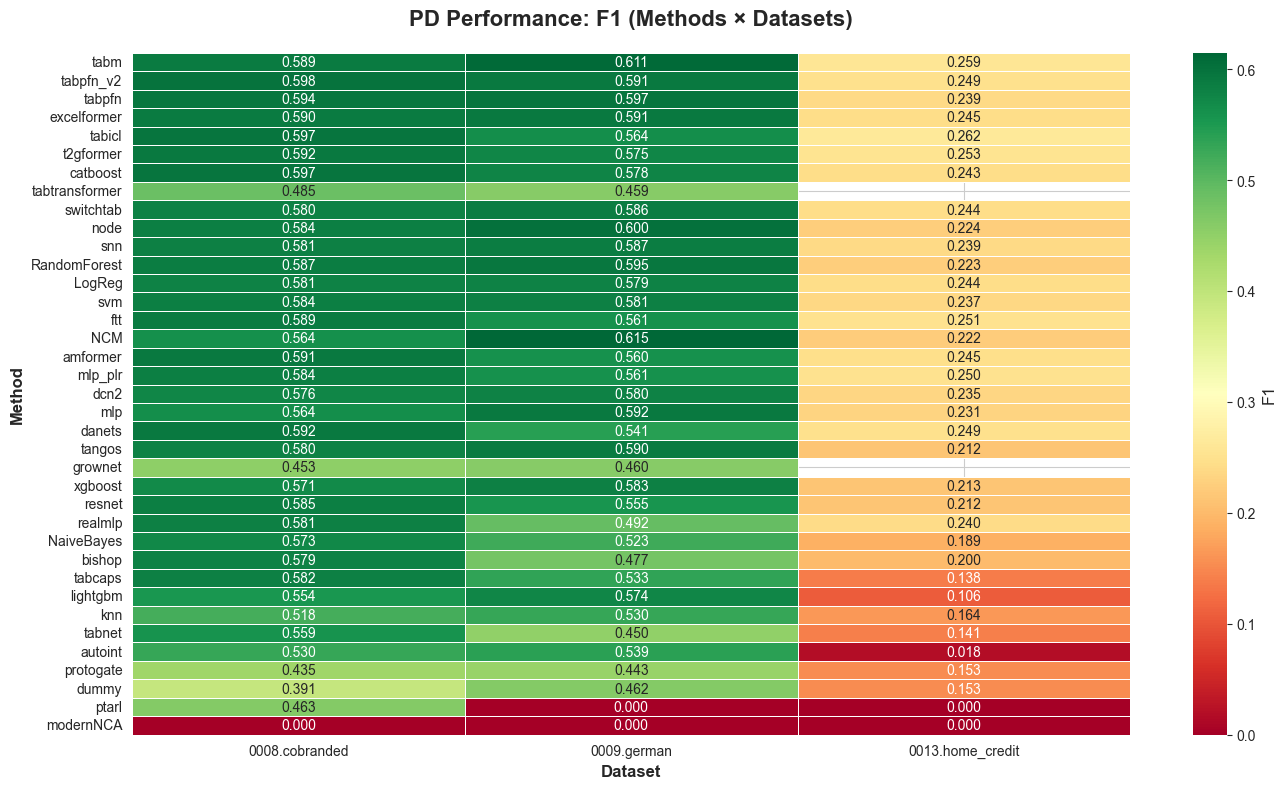

In [6]:
# PD: F1 Heatmap
print("Creating PD F1 heatmap...")
fig_pd_f1, pivot_pd_f1 = create_performance_heatmap(
    pd_agg, 'F1', 'PD', cmap='RdYlGn'
)
plt.show()

### 3.2 Method Rankings (PD)

In [7]:
def create_method_ranking(df, metrics, task_name):
    """
    Create a ranking table for methods across multiple metrics.
    
    Args:
        df: Aggregated dataframe
        metrics: List of metrics to include
        task_name: 'PD' or 'LGD'
    """
    rankings = []
    
    for metric in metrics:
        mean_col = f'{metric}_mean'
        std_col = f'{metric}_std'
        
        if mean_col not in df.columns:
            continue
        
        # Calculate average across datasets for each method
        method_stats = df.groupby('method').agg({
            mean_col: 'mean',
            std_col: 'mean',
            'dataset': 'count'
        }).rename(columns={'dataset': 'n_datasets'})
        
        method_stats = method_stats.sort_values(mean_col, ascending=False)
        method_stats['rank'] = range(1, len(method_stats) + 1)
        method_stats['metric'] = metric
        
        rankings.append(method_stats.reset_index())
    
    ranking_df = pd.concat(rankings, ignore_index=True)
    
    # Create pivot table: methods × metrics showing ranks
    rank_pivot = ranking_df.pivot(index='method', columns='metric', values='rank')
    
    # Add average rank
    rank_pivot['Avg_Rank'] = rank_pivot.mean(axis=1)
    rank_pivot = rank_pivot.sort_values('Avg_Rank')
    
    print(f"\n{'='*80}")
    print(f"  {task_name} METHOD RANKINGS (across all datasets)")
    print(f"{'='*80}")
    print(rank_pivot.to_string())
    print(f"\n(Lower rank = better performance)\n")
    
    return rank_pivot

# Create PD rankings
pd_rankings = create_method_ranking(pd_agg, ['AUC', 'F1'], 'PD')


  PD METHOD RANKINGS (across all datasets)
metric          AUC  F1  Avg_Rank
method                           
tabm              3   1       2.0
tabicl            2   5       3.5
tabpfn            4   3       3.5
tabpfn_v2         6   2       4.0
tabtransformer    1   8       4.5
t2gformer         5   6       5.5
excelformer       9   4       6.5
catboost          8   7       7.5
snn               7  11       9.0
ftt              10  15      12.5
LogReg           12  13      12.5
NCM              11  16      13.5
switchtab        19   9      14.0
svm              14  14      14.0
RandomForest     18  12      15.0
node             20  10      15.0
amformer         15  17      16.0
mlp              13  20      16.5
mlp_plr          16  18      17.0
dcn2             17  19      18.0
tangos           21  22      21.5
danets           26  21      23.5
resnet           23  25      24.0
realmlp          24  26      25.0
xgboost          27  24      25.5
lightgbm         25  30      27.5
grow

✅ Saved: pd_bar_auc.png


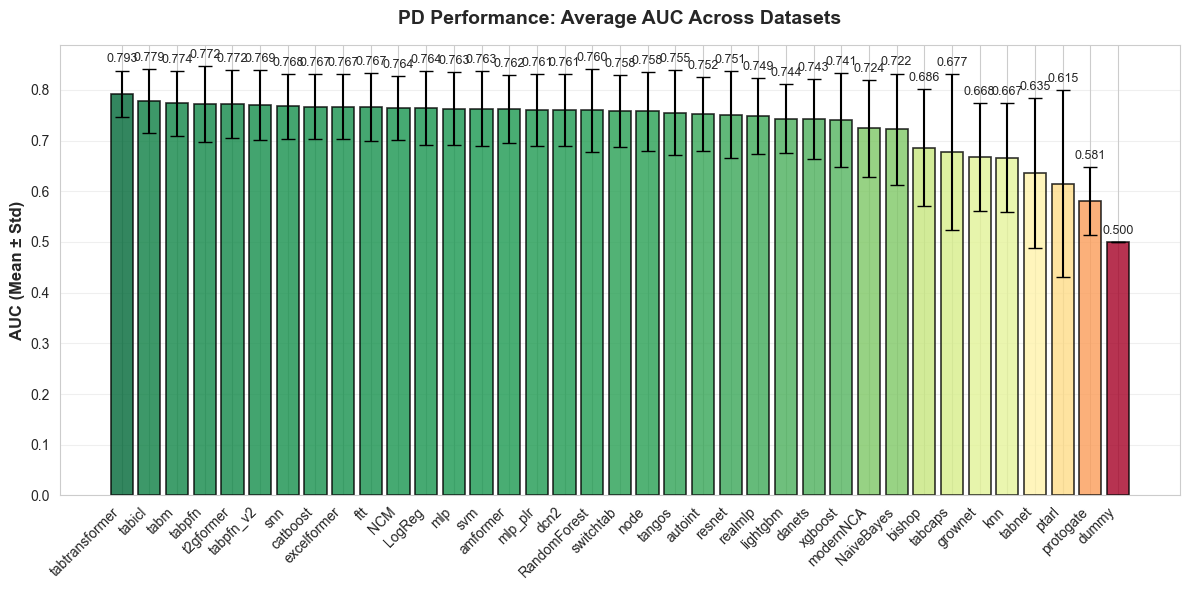

In [8]:
# Bar chart: Average performance across datasets
def plot_average_performance(df, metric, task_name, figsize=(12, 6)):
    """
    Create a bar chart showing average performance across datasets.
    """
    mean_col = f'{metric}_mean'
    std_col = f'{metric}_std'
    
    if mean_col not in df.columns:
        print(f"⚠️  Metric '{metric}' not found")
        return None
    
    # Calculate average across datasets
    method_avg = df.groupby('method')[mean_col].mean().sort_values(ascending=False)
    method_std = df.groupby('method')[mean_col].std()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    x = np.arange(len(method_avg))
    bars = ax.bar(x, method_avg.values, yerr=method_std.loc[method_avg.index].values,
                   capsize=5, alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Color bars by performance (gradient)
    norm = plt.Normalize(vmin=method_avg.min(), vmax=method_avg.max())
    colors = plt.cm.RdYlGn(norm(method_avg.values))
    for bar, color in zip(bars, colors):
        bar.set_facecolor(color)
    
    ax.set_xticks(x)
    ax.set_xticklabels(method_avg.index, rotation=45, ha='right')
    ax.set_ylabel(f'{metric} (Mean ± Std)', fontsize=12, fontweight='bold')
    ax.set_title(f'{task_name} Performance: Average {metric} Across Datasets',
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (val, std) in enumerate(zip(method_avg.values, method_std.loc[method_avg.index].values)):
        ax.text(i, val + std + 0.01, f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    filename = FIGURES_DIR / f"{task_name.lower()}_bar_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename.name}")
    
    return fig

# PD: Average AUC
plot_average_performance(pd_agg, 'AUC', 'PD')
plt.show()

✅ Saved: pd_bar_f1.png


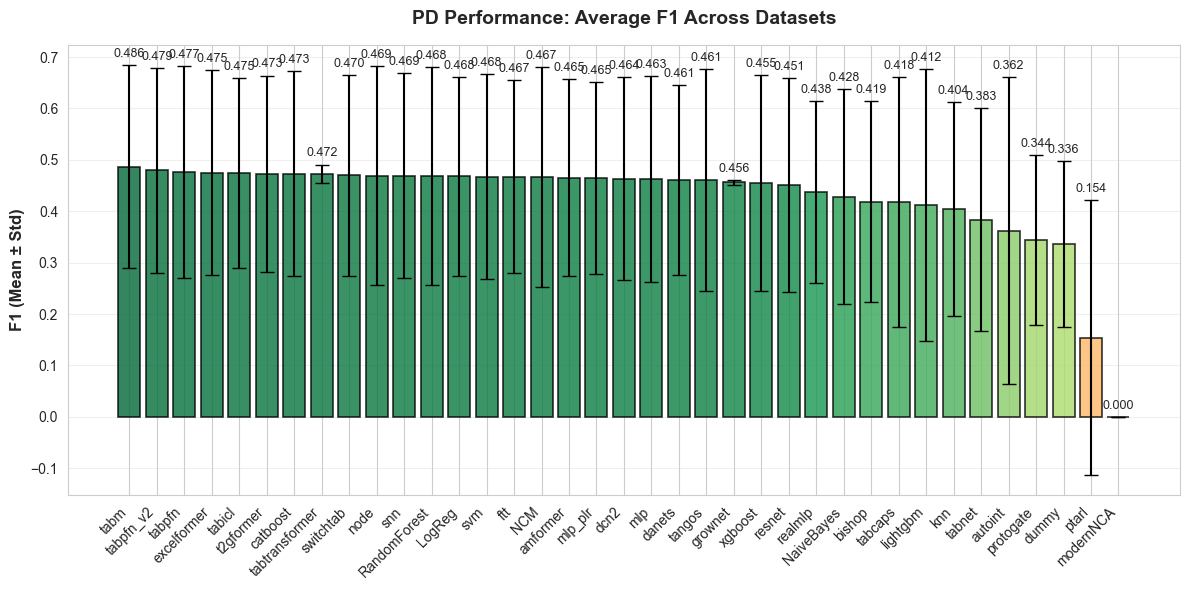

In [9]:
# PD: Average F1
plot_average_performance(pd_agg, 'F1', 'PD')
plt.show()

### 3.3 Performance Distribution (PD)

✅ Saved: pd_boxplot_auc.png


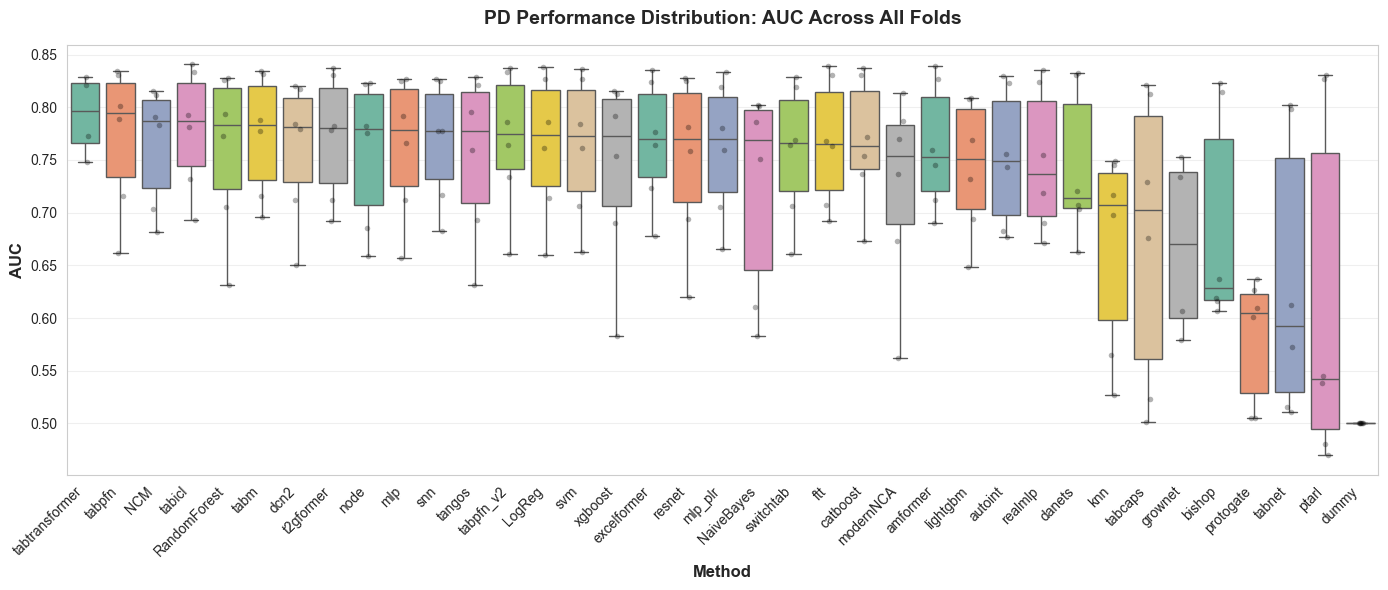

In [10]:
def plot_performance_distribution(df, metric, task_name, figsize=(14, 6)):
    """
    Create boxplot showing distribution of performance across datasets.
    """
    if metric not in df.columns:
        print(f"⚠️  Metric '{metric}' not found")
        return None
    
    # Calculate method order by median performance
    method_order = df.groupby('method')[metric].median().sort_values(ascending=False).index
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create boxplot
    sns.boxplot(
        data=df,
        x='method',
        y=metric,
        order=method_order,
        palette='Set2',
        ax=ax
    )
    
    # Add individual points
    sns.stripplot(
        data=df,
        x='method',
        y=metric,
        order=method_order,
        color='black',
        alpha=0.3,
        size=4,
        ax=ax
    )
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Method', fontsize=12, fontweight='bold')
    ax.set_title(f'{task_name} Performance Distribution: {metric} Across All Folds',
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    filename = FIGURES_DIR / f"{task_name.lower()}_boxplot_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename.name}")
    
    return fig

# PD: AUC distribution
plot_performance_distribution(pd_raw, 'AUC', 'PD')
plt.show()

✅ Saved: pd_boxplot_f1.png


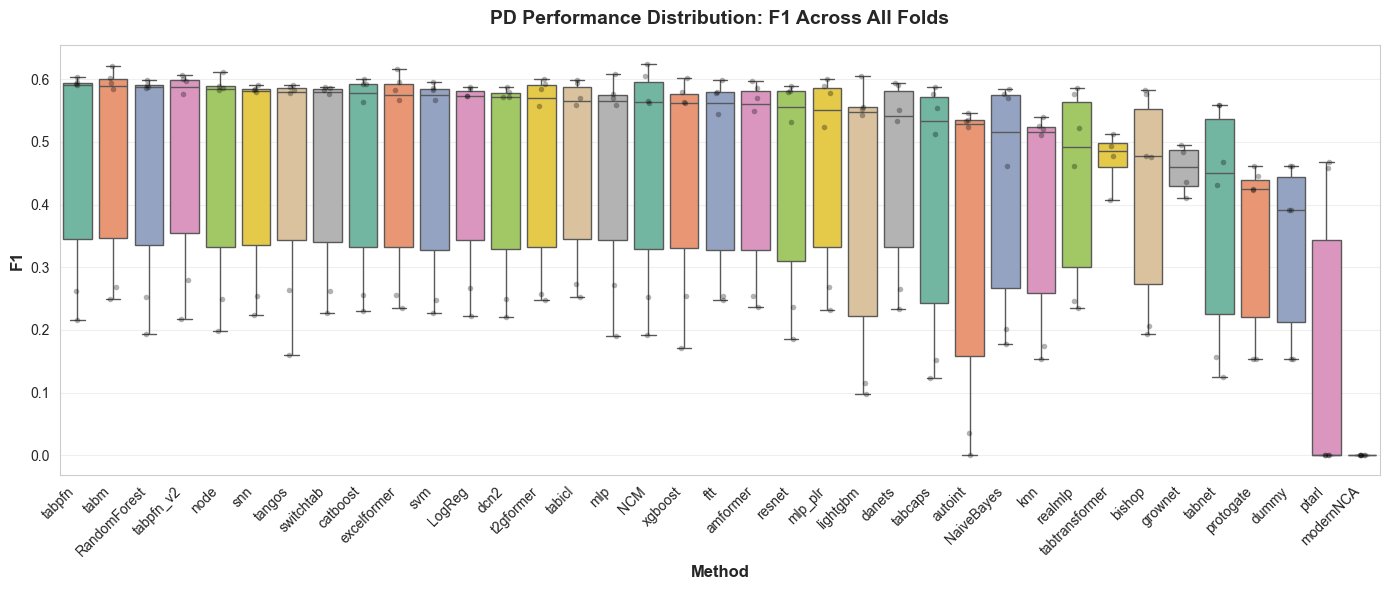

In [11]:
# PD: F1 distribution
plot_performance_distribution(pd_raw, 'F1', 'PD')
plt.show()

## 4. Performance Analysis: LGD Task

### 4.1 Performance Heatmaps (Methods × Datasets)

Creating LGD R2 heatmap...
✅ Saved: lgd_heatmap_r2.png


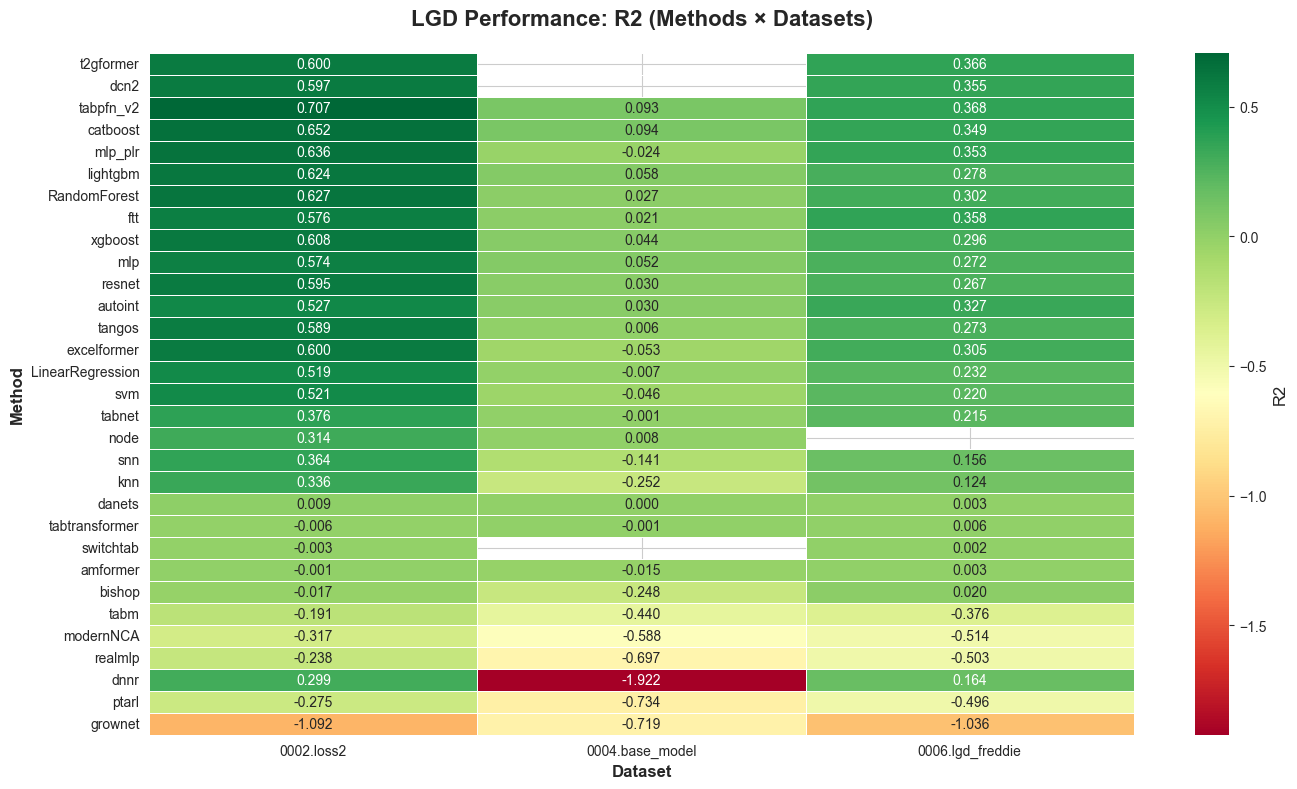

In [12]:
# LGD: R2 Heatmap
print("Creating LGD R2 heatmap...")
fig_lgd_r2, pivot_lgd_r2 = create_performance_heatmap(
    lgd_agg, 'R2', 'LGD', cmap='RdYlGn'
)
plt.show()

### 4.2 Method Rankings (LGD)

In [13]:
# Create LGD rankings
lgd_rankings = create_method_ranking(lgd_agg, ['R2'], 'LGD')


  LGD METHOD RANKINGS (across all datasets)
metric            R2  Avg_Rank
method                        
t2gformer          1       1.0
dcn2               2       2.0
tabpfn_v2          3       3.0
catboost           4       4.0
mlp_plr            5       5.0
lightgbm           6       6.0
RandomForest       7       7.0
ftt                8       8.0
xgboost            9       9.0
mlp               10      10.0
resnet            11      11.0
autoint           12      12.0
tangos            13      13.0
excelformer       14      14.0
LinearRegression  15      15.0
svm               16      16.0
tabnet            17      17.0
node              18      18.0
snn               19      19.0
knn               20      20.0
danets            21      21.0
tabtransformer    22      22.0
switchtab         23      23.0
amformer          24      24.0
bishop            25      25.0
tabm              26      26.0
modernNCA         27      27.0
realmlp           28      28.0
dnnr              29     

✅ Saved: lgd_bar_r2.png


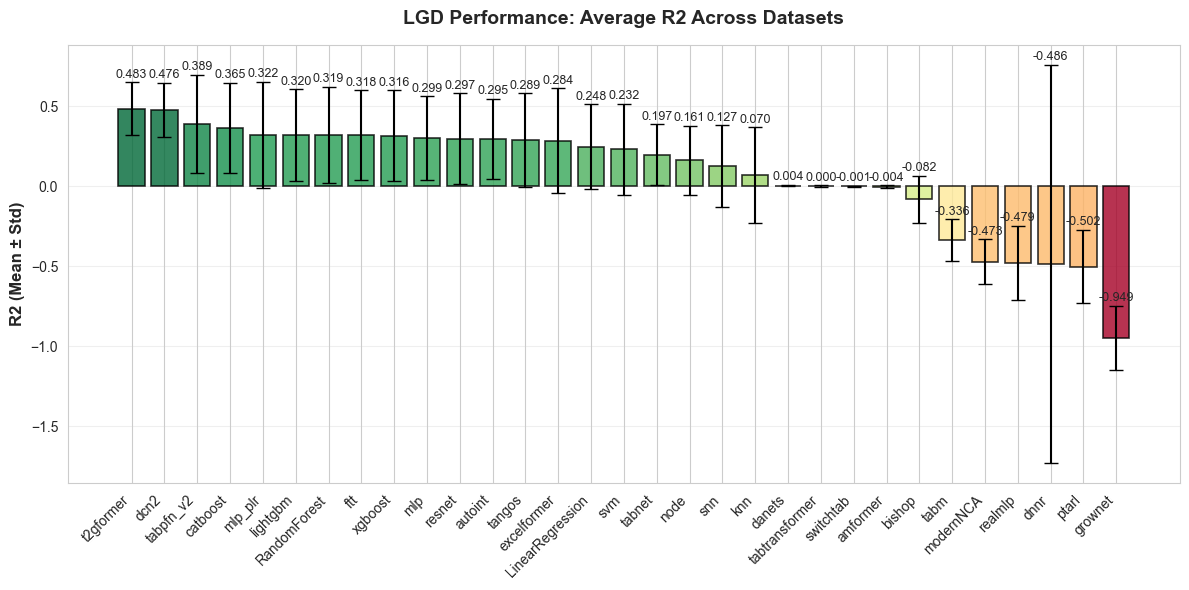

In [14]:
# LGD: Average R2
plot_average_performance(lgd_agg, 'R2', 'LGD')
plt.show()

### 4.3 Performance Distribution (LGD)

✅ Saved: lgd_boxplot_r2.png


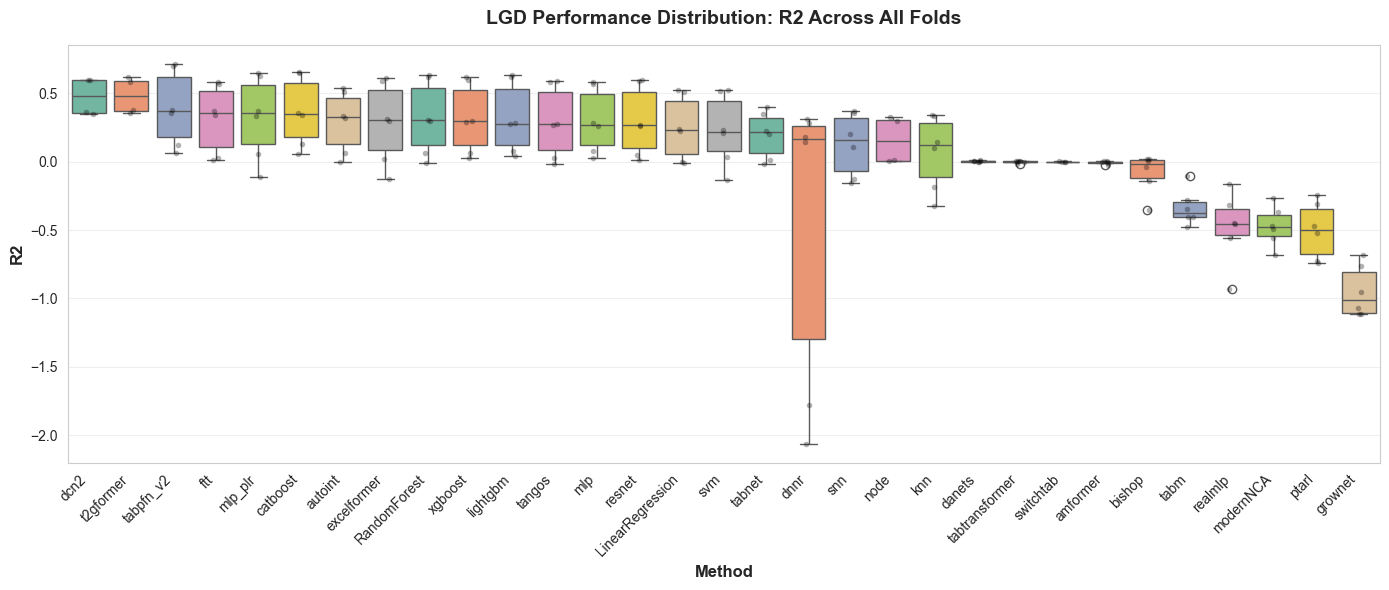

In [15]:
# LGD: R2 distribution
plot_performance_distribution(lgd_raw, 'R2', 'LGD')
plt.show()

## 5. Training Time Analysis

### 5.1 Average Training Time per Method

✅ Saved: training_time_comparison.png


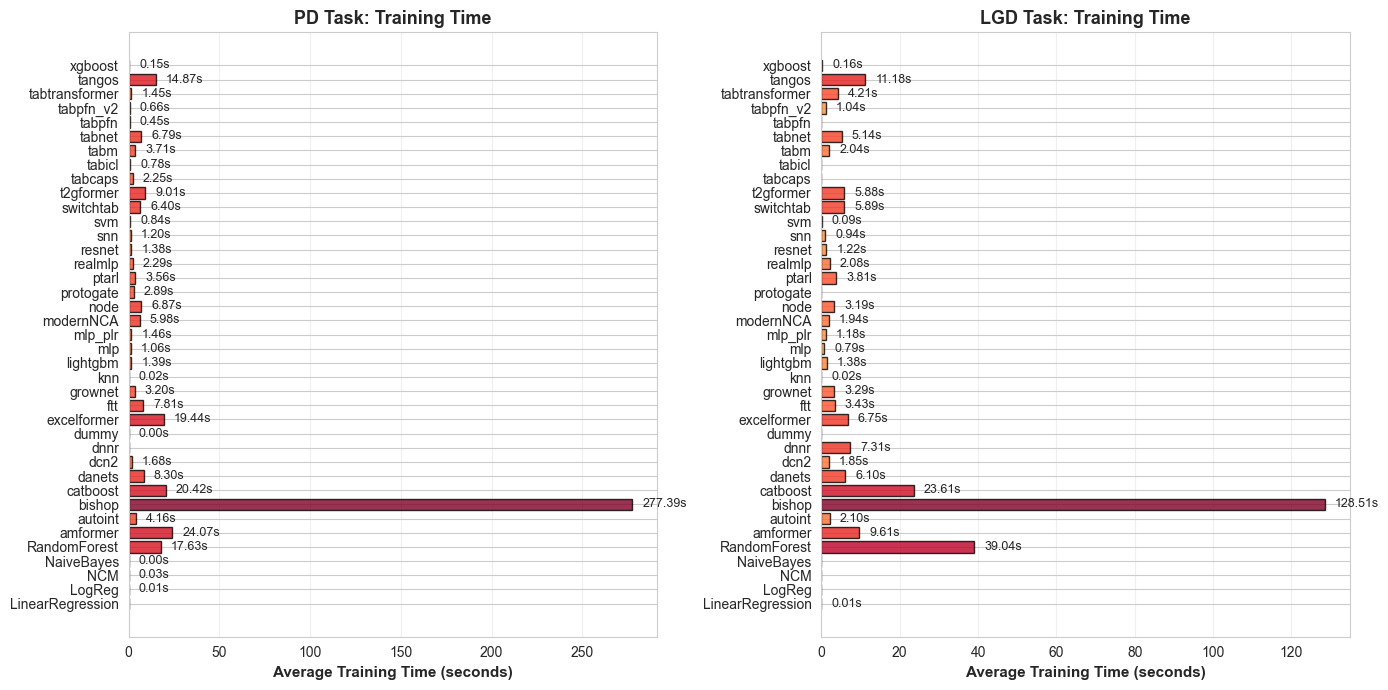

In [16]:
def plot_training_time(df_pd, df_lgd, figsize=(14, 7)):
    """
    Create a bar chart comparing training times across methods.
    """
    # Calculate average training time for each method (across all folds and datasets)
    pd_time = df_pd.groupby('method')['train_time'].mean().sort_values()
    lgd_time = df_lgd.groupby('method')['train_time'].mean().sort_values()
    
    # Combine
    all_methods = sorted(set(pd_time.index) | set(lgd_time.index))
    
    pd_values = [pd_time.get(m, 0) for m in all_methods]
    lgd_values = [lgd_time.get(m, 0) for m in all_methods]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # PD plot
    y_pos = np.arange(len(all_methods))
    bars1 = ax1.barh(y_pos, pd_values, alpha=0.8, edgecolor='black', linewidth=1)
    
    # Color by time (log scale for better visualization)
    norm = plt.Normalize(vmin=np.log10(min([v for v in pd_values if v > 0]) + 1e-6),
                         vmax=np.log10(max(pd_values) + 1e-6))
    colors = plt.cm.YlOrRd(norm(np.log10(np.array(pd_values) + 1e-6)))
    for bar, color in zip(bars1, colors):
        bar.set_facecolor(color)
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(all_methods)
    ax1.set_xlabel('Average Training Time (seconds)', fontsize=11, fontweight='bold')
    ax1.set_title('PD Task: Training Time', fontsize=13, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(pd_values):
        if v > 0:
            ax1.text(v + max(pd_values)*0.02, i, f'{v:.2f}s', va='center', fontsize=9)
    
    # LGD plot
    bars2 = ax2.barh(y_pos, lgd_values, alpha=0.8, edgecolor='black', linewidth=1)
    
    norm = plt.Normalize(vmin=np.log10(min([v for v in lgd_values if v > 0]) + 1e-6),
                         vmax=np.log10(max(lgd_values) + 1e-6))
    colors = plt.cm.YlOrRd(norm(np.log10(np.array(lgd_values) + 1e-6)))
    for bar, color in zip(bars2, colors):
        bar.set_facecolor(color)
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(all_methods)
    ax2.set_xlabel('Average Training Time (seconds)', fontsize=11, fontweight='bold')
    ax2.set_title('LGD Task: Training Time', fontsize=13, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(lgd_values):
        if v > 0:
            ax2.text(v + max(lgd_values)*0.02, i, f'{v:.2f}s', va='center', fontsize=9)
    
    plt.tight_layout()
    
    filename = FIGURES_DIR / "training_time_comparison.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename.name}")
    
    return fig

plot_training_time(pd_raw, lgd_raw)
plt.show()

### 5.2 Training Time Statistics

In [17]:
# Detailed training time statistics
def training_time_statistics(df_pd, df_lgd):
    """
    Create a comprehensive table of training time statistics.
    """
    stats = []
    
    for task, df in [('PD', df_pd), ('LGD', df_lgd)]:
        for method in df['method'].unique():
            method_df = df[df['method'] == method]['train_time']
            
            stats.append({
                'Task': task,
                'Method': method,
                'Mean (s)': method_df.mean(),
                'Median (s)': method_df.median(),
                'Std (s)': method_df.std(),
                'Min (s)': method_df.min(),
                'Max (s)': method_df.max(),
                'N_Runs': len(method_df)
            })
    
    stats_df = pd.DataFrame(stats)
    
    print("\n" + "="*100)
    print("  TRAINING TIME STATISTICS")
    print("="*100)
    
    for task in ['PD', 'LGD']:
        task_df = stats_df[stats_df['Task'] == task].sort_values('Mean (s)')
        print(f"\n{task} Task:")
        print(task_df.to_string(index=False))
    
    return stats_df

time_stats = training_time_statistics(pd_raw, lgd_raw)


  TRAINING TIME STATISTICS

PD Task:
Task         Method   Mean (s)  Median (s)    Std (s)   Min (s)    Max (s)  N_Runs
  PD          dummy   0.000920    0.000938   0.000108  0.000776   0.001060       6
  PD     NaiveBayes   0.003384    0.002942   0.002315  0.000983   0.006757       6
  PD         LogReg   0.014930    0.015499   0.011561  0.002141   0.031829       6
  PD            knn   0.016396    0.016254   0.012440  0.002038   0.030395       6
  PD            NCM   0.025470    0.013305   0.037061  0.001415   0.097913       6
  PD        xgboost   0.146128    0.118459   0.102349  0.028494   0.309455       6
  PD         tabpfn   0.452258    0.301476   0.599356  0.012840   1.604662       6
  PD      tabpfn_v2   0.664592    0.621364   0.454494  0.122710   1.406746       6
  PD         tabicl   0.775036    0.764248   0.277848  0.432582   1.185753       6
  PD            svm   0.838713    0.888980   0.686468  0.044174   1.586112       6
  PD            mlp   1.056140    1.221014   0.58

### 5.3 Performance vs. Training Time Trade-off

✅ Saved: pd_perf_vs_time_auc.png


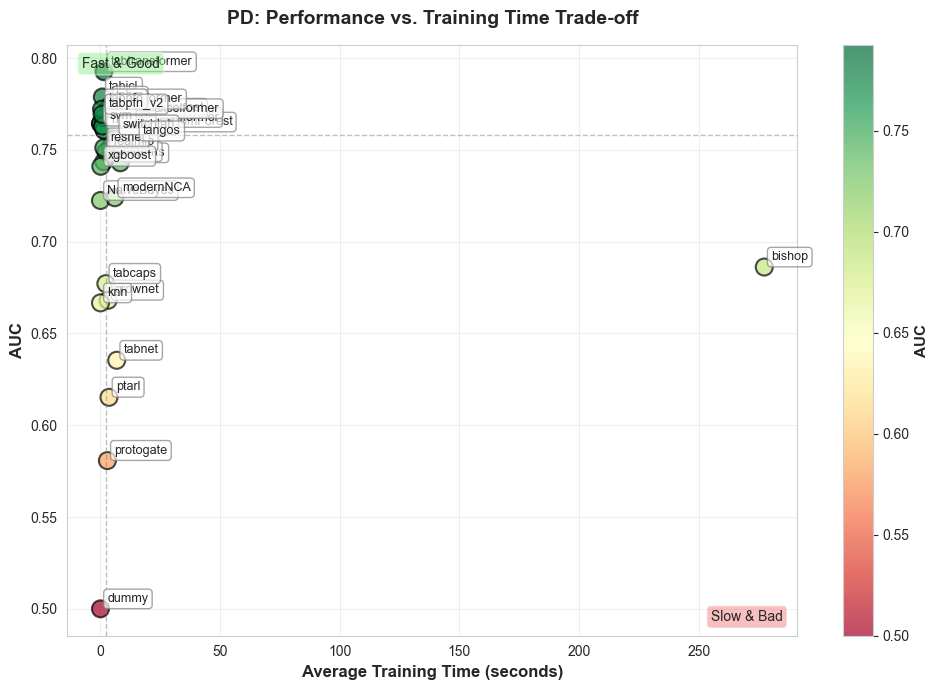

In [18]:
def plot_performance_vs_time(df_raw, df_agg, metric, task_name, figsize=(10, 7)):
    """
    Scatter plot: Performance vs. Training Time.
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df_agg.columns:
        print(f"⚠️  Metric '{metric}' not found")
        return None
    
    # Calculate average performance and time per method
    method_perf = df_agg.groupby('method')[mean_col].mean()
    method_time = df_raw.groupby('method')['train_time'].mean()
    
    # Combine
    data = pd.DataFrame({
        'method': method_perf.index,
        'performance': method_perf.values,
        'time': method_time.loc[method_perf.index].values
    })
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create scatter plot
    scatter = ax.scatter(
        data['time'],
        data['performance'],
        s=150,
        alpha=0.7,
        c=data['performance'],
        cmap='RdYlGn',
        edgecolors='black',
        linewidth=1.5
    )
    
    # Add method labels
    for _, row in data.iterrows():
        ax.annotate(
            row['method'],
            (row['time'], row['performance']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray')
        )
    
    ax.set_xlabel('Average Training Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_title(f'{task_name}: Performance vs. Training Time Trade-off',
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(metric, fontsize=11, fontweight='bold')
    
    # Add quadrant lines (median performance and time)
    ax.axhline(data['performance'].median(), color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(data['time'].median(), color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Annotate quadrants
    ax.text(0.02, 0.98, 'Fast & Good', transform=ax.transAxes,
            fontsize=10, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    ax.text(0.98, 0.02, 'Slow & Bad', transform=ax.transAxes,
            fontsize=10, va='bottom', ha='right', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
    
    plt.tight_layout()
    
    filename = FIGURES_DIR / f"{task_name.lower()}_perf_vs_time_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename.name}")
    
    return fig, data

# PD: AUC vs Time
fig_pd_tradeoff, data_pd_tradeoff = plot_performance_vs_time(pd_raw, pd_agg, 'AUC', 'PD')
plt.show()

✅ Saved: lgd_perf_vs_time_r2.png


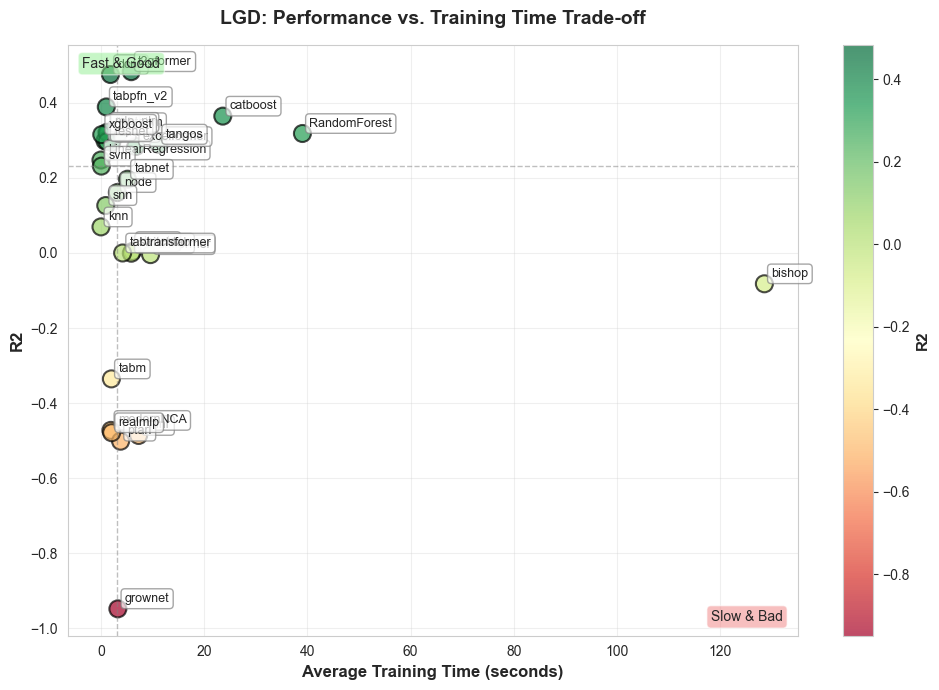

In [19]:
# LGD: R2 vs Time
fig_lgd_tradeoff, data_lgd_tradeoff = plot_performance_vs_time(lgd_raw, lgd_agg, 'R2', 'LGD')
plt.show()

## 7. Method Selection Recommendations

### 7.1 Selection Criteria

In [22]:
def recommend_methods(
    df_raw,
    df_agg,
    metric,
    task_name,
    performance_threshold_percentile=75,
    time_threshold_percentile=75,
    min_datasets=2
):
    """
    Recommend methods for full benchmark based on multiple criteria:
    1. Performance above threshold
    2. Training time below threshold
    3. Consistency across datasets
    
    Args:
        df_raw: Raw results
        df_agg: Aggregated results
        metric: Primary metric for ranking
        task_name: 'PD' or 'LGD'
        performance_threshold_percentile: Include methods above this percentile
        time_threshold_percentile: Exclude methods above this percentile
        min_datasets: Minimum number of datasets method must have results on
    """
    mean_col = f'{metric}_mean'
    std_col = f'{metric}_std'
    
    if mean_col not in df_agg.columns:
        print(f"⚠️  Metric '{metric}' not found")
        return None
    
    # Calculate method statistics
    method_stats = []
    
    for method in df_raw['method'].unique():
        method_raw = df_raw[df_raw['method'] == method]
        method_agg = df_agg[df_agg['method'] == method]
        
        # Performance
        perf_mean = method_agg[mean_col].mean()
        perf_std = method_raw[metric].std()
        
        # Training time
        time_mean = method_raw['train_time'].mean()
        time_std = method_raw['train_time'].std()
        
        # Consistency (coefficient of variation)
        cv = (perf_std / perf_mean) if perf_mean > 0 else np.inf
        
        # Number of datasets
        n_datasets = method_agg['dataset'].nunique()
        
        method_stats.append({
            'Method': method,
            f'{metric}_Mean': perf_mean,
            f'{metric}_Std': perf_std,
            'CV': cv,
            'Time_Mean': time_mean,
            'Time_Std': time_std,
            'N_Datasets': n_datasets
        })
    
    stats_df = pd.DataFrame(method_stats)
    
    # Apply thresholds
    perf_threshold = np.percentile(stats_df[f'{metric}_Mean'], performance_threshold_percentile)
    time_threshold = np.percentile(stats_df['Time_Mean'], time_threshold_percentile)
    
    # Filter
    recommended = stats_df[
        (stats_df[f'{metric}_Mean'] >= perf_threshold) &
        (stats_df['Time_Mean'] <= time_threshold) &
        (stats_df['N_Datasets'] >= min_datasets)
    ].copy()
    
    # Rank by performance
    recommended = recommended.sort_values(f'{metric}_Mean', ascending=False)
    recommended['Rank'] = range(1, len(recommended) + 1)
    
    # Also show all methods for comparison
    all_methods = stats_df.sort_values(f'{metric}_Mean', ascending=False)
    all_methods['Rank'] = range(1, len(all_methods) + 1)
    
    print(f"\n{'='*100}")
    print(f"  METHOD SELECTION RECOMMENDATIONS: {task_name}")
    print(f"{'='*100}")
    print(f"\nSelection Criteria:")
    print(f"  - {metric} ≥ {perf_threshold:.4f} ({performance_threshold_percentile}th percentile)")
    print(f"  - Training Time ≤ {time_threshold:.4f}s ({time_threshold_percentile}th percentile)")
    print(f"  - Available on ≥ {min_datasets} datasets")
    print(f"\n{'─'*100}")
    print(f"  RECOMMENDED METHODS ({len(recommended)} selected):")
    print(f"{'─'*100}")
    print(recommended.to_string(index=False))
    
    print(f"\n{'─'*100}")
    print(f"  ALL METHODS (for comparison):")
    print(f"{'─'*100}")
    print(all_methods.to_string(index=False))
    print()
    
    return recommended, all_methods

# PD recommendations
pd_recommended, pd_all = recommend_methods(
    pd_raw, pd_agg, 'AUC', 'PD',
    performance_threshold_percentile=70,
    time_threshold_percentile=80
)


  METHOD SELECTION RECOMMENDATIONS: PD

Selection Criteria:
  - AUC ≥ 0.7642 (70th percentile)
  - Training Time ≤ 8.1998s (80th percentile)
  - Available on ≥ 2 datasets

────────────────────────────────────────────────────────────────────────────────────────────────────
  RECOMMENDED METHODS (8 selected):
────────────────────────────────────────────────────────────────────────────────────────────────────
        Method  AUC_Mean  AUC_Std       CV  Time_Mean  Time_Std  N_Datasets  Rank
tabtransformer  0.792564 0.038803 0.048959   1.451102  0.332892           2     1
        tabicl  0.778779 0.057718 0.074114   0.775036  0.277848           3     2
          tabm  0.773863 0.057759 0.074637   3.711916  2.389730           3     3
        tabpfn  0.772150 0.068849 0.089165   0.452258  0.599356           3     4
     tabpfn_v2  0.769357 0.066338 0.086225   0.664592  0.454494           3     5
           snn  0.767656 0.057917 0.075446   1.202454  0.550250           3     6
           ftt 

In [23]:
# LGD recommendations
lgd_recommended, lgd_all = recommend_methods(
    lgd_raw, lgd_agg, 'R2', 'LGD',
    performance_threshold_percentile=70,
    time_threshold_percentile=80
)


  METHOD SELECTION RECOMMENDATIONS: LGD

Selection Criteria:
  - R2 ≥ 0.2991 (70th percentile)
  - Training Time ≤ 6.7465s (80th percentile)
  - Available on ≥ 2 datasets

────────────────────────────────────────────────────────────────────────────────────────────────────
  RECOMMENDED METHODS (8 selected):
────────────────────────────────────────────────────────────────────────────────────────────────────
   Method  R2_Mean   R2_Std       CV  Time_Mean  Time_Std  N_Datasets  Rank
t2gformer 0.483433 0.136159 0.281651   5.881333  1.269223           2     1
     dcn2 0.475897 0.139536 0.293206   1.850173  0.484526           2     2
tabpfn_v2 0.389403 0.275860 0.708417   1.044851  0.405474           3     3
  mlp_plr 0.321855 0.301380 0.936385   1.176364  0.614510           3     4
 lightgbm 0.319947 0.255876 0.799746   1.382082  0.593080           3     5
      ftt 0.318392 0.250480 0.786703   3.430918  1.753940           3     6
  xgboost 0.315731 0.253174 0.801864   0.163749  0.072299

## 8. Final Summary & Recommendations

### 8.1 Executive Summary

In [25]:
print("\n" + "="*100)
print("  EXPERIMENT0 EXECUTIVE SUMMARY")
print("="*100)

print("\n📊 EXPERIMENT OVERVIEW:")
print(f"  - PD Datasets: {pd_raw['dataset'].nunique()}")
print(f"  - LGD Datasets: {lgd_raw['dataset'].nunique()}")
print(f"  - PD Methods Tested: {pd_raw['method'].nunique()}")
print(f"  - LGD Methods Tested: {lgd_raw['method'].nunique()}")
print(f"  - Total Evaluations: {len(pd_raw) + len(lgd_raw)}")

print("\n🏆 TOP 5 METHODS (by average performance):")
print("\n  PD Task (AUC):")
pd_top5 = pd_raw.groupby('method')['AUC'].mean().sort_values(ascending=False).head(5)
for i, (method, score) in enumerate(pd_top5.items(), 1):
    print(f"    {i}. {method:20s} - AUC: {score:.4f}")

print("\n  LGD Task (R2):")
lgd_top5 = lgd_raw.groupby('method')['R2'].mean().sort_values(ascending=False).head(5)
for i, (method, score) in enumerate(lgd_top5.items(), 1):
    print(f"    {i}. {method:20s} - R2: {score:.4f}")

print("\n⚡ FASTEST METHODS (by training time):")
print("\n  PD Task:")
pd_fast5 = pd_raw.groupby('method')['train_time'].mean().sort_values().head(5)
for i, (method, time) in enumerate(pd_fast5.items(), 1):
    print(f"    {i}. {method:20s} - {time:.4f}s")

print("\n  LGD Task:")
lgd_fast5 = lgd_raw.groupby('method')['train_time'].mean().sort_values().head(5)
for i, (method, time) in enumerate(lgd_fast5.items(), 1):
    print(f"    {i}. {method:20s} - {time:.4f}s")

if pd_recommended is not None:
    print(f"\n✅ RECOMMENDED FOR EXPERIMENT1:")
    print(f"\n  PD Methods ({len(pd_recommended)}):")
    for method in pd_recommended['Method']:
        print(f"    - {method}")

if lgd_recommended is not None:
    print(f"\n  LGD Methods ({len(lgd_recommended)}):")
    for method in lgd_recommended['Method']:
        print(f"    - {method}")

print("\n" + "="*100)
print("  📁 All results and figures saved to: " + str(RESULTS_DIR))
print("="*100 + "\n")


  EXPERIMENT0 EXECUTIVE SUMMARY

📊 EXPERIMENT OVERVIEW:
  - PD Datasets: 3
  - LGD Datasets: 3
  - PD Methods Tested: 37
  - LGD Methods Tested: 31
  - Total Evaluations: 396

🏆 TOP 5 METHODS (by average performance):

  PD Task (AUC):
    1. tabtransformer       - AUC: 0.7926
    2. tabicl               - AUC: 0.7788
    3. tabm                 - AUC: 0.7739
    4. tabpfn               - AUC: 0.7722
    5. t2gformer            - AUC: 0.7721

  LGD Task (R2):
    1. t2gformer            - R2: 0.4834
    2. dcn2                 - R2: 0.4759
    3. tabpfn_v2            - R2: 0.3894
    4. catboost             - R2: 0.3649
    5. mlp_plr              - R2: 0.3219

⚡ FASTEST METHODS (by training time):

  PD Task:
    1. dummy                - 0.0009s
    2. NaiveBayes           - 0.0034s
    3. LogReg               - 0.0149s
    4. knn                  - 0.0164s
    5. NCM                  - 0.0255s

  LGD Task:
    1. LinearRegression     - 0.0101s
    2. knn                  - 0.0156s


### 8.2 Next Steps

Based on this analysis, the following steps are recommended for **Experiment1**:

1. **Include Recommended Methods**: Use the recommended methods identified above
2. **Run Full Benchmark**: Test on all datasets with both NO_HPO and HPO configurations
3. **Monitor Computational Cost**: Track total runtime and resource usage
4. **Consider Method Variants**: For top-performing methods, test multiple hyperparameter configurations
5. **Ensemble Methods**: Consider combining predictions from top methods

---

## 📝 Notes

- Figures saved to: `results/experiment0/figures/`
- Summary CSVs available in: `results/experiment0/summary/`
- Recommended methods exported for easy integration into Experiment1

---